In [15]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Distributed_PageRank_RDD") \
    .getOrCreate()

sc = spark.sparkContext

print("Spark Version:", spark.version)
print("Spark Master:", sc.master)

Spark Version: 4.0.4
Spark Master: local[*]


In [16]:
numbers = sc.parallelize([1, 2, 3, 4, 5])

result = numbers.map(lambda x: x * 2).collect()

print(result)

[2, 4, 6, 8, 10]


In [17]:
import random
import math
import matplotlib.pyplot as plt

In [18]:
NUM_NODES = 5000
LINKS_PER_NODE = 5

random.seed(42)

edges = []

for node in range(NUM_NODES):
    targets = set()

    while len(targets) < LINKS_PER_NODE:
        target = random.randint(0, NUM_NODES - 1)

        if target != node:
            targets.add(target)

    for target in targets:
        edges.append((node, target))

print("Number of documents:", NUM_NODES)
print("Number of links:", len(edges))

Number of documents: 5000
Number of links: 25000


In [19]:
edges_rdd = sc.parallelize(edges)

print("Number of partitions:", edges_rdd.getNumPartitions())
print("\nSample edges:")

for edge in edges_rdd.take(10):
    print(edge)

Number of partitions: 2

Sample edges:
(0, 1828)
(0, 204)
(0, 2253)
(0, 912)
(0, 2006)
(1, 4837)
(1, 839)
(1, 712)
(1, 4467)
(1, 1143)


In [20]:
adjacency_rdd = edges_rdd \
    .groupByKey() \
    .mapValues(list) \
    .cache()

print("Sample adjacency lists:\n")

for item in adjacency_rdd.take(5):
    print(item)

Sample adjacency lists:

(0, [1828, 204, 2253, 912, 2006])
(2, [3456, 260, 767, 244, 1791])
(4, [3436, 1805, 4464, 1628, 3679])
(6, [2787, 2276, 2757, 1763, 1273])
(8, [2817, 355, 4945, 3763, 2166])


In [21]:
initial_rank = 1.0 / NUM_NODES

ranks = sc.parallelize(
    [(node, initial_rank) for node in range(NUM_NODES)]
)

print("Initial PageRank:", initial_rank)

print("\nSample initial ranks:")
for item in ranks.take(5):
    print(item)

Initial PageRank: 0.0002

Sample initial ranks:
(0, 0.0002)
(1, 0.0002)
(2, 0.0002)
(3, 0.0002)
(4, 0.0002)


In [22]:
DAMPING = 0.85
MAX_ITERATIONS = 50
TOLERANCE = 0.000001

print("Damping factor:", DAMPING)
print("Maximum iterations:", MAX_ITERATIONS)
print("Convergence tolerance:", TOLERANCE)

Damping factor: 0.85
Maximum iterations: 50
Convergence tolerance: 1e-06


In [14]:
convergence_history = []

for iteration in range(MAX_ITERATIONS):

    # Join adjacency list with current PageRank
    joined = adjacency_rdd.join(ranks)

    # Distribute PageRank to linked pages
    contributions = joined.flatMap(
        lambda x: [
            (
                destination,
                x[1][1] / len(x[1][0])
            )
            for destination in x[1][0]
        ]
    )

    # Add contributions received by each page
    new_ranks = contributions.reduceByKey(
        lambda x, y: x + y
    )

    # Apply damping factor
    new_ranks = new_ranks.mapValues(
        lambda rank:
        (1 - DAMPING) / NUM_NODES
        + DAMPING * rank
    )

    # Add missing nodes with zero rank
    all_nodes = sc.parallelize(range(NUM_NODES))

    new_ranks = all_nodes.map(
        lambda node: (node, 0.0)
    ).leftOuterJoin(new_ranks).mapValues(
        lambda value:
        value[1] if value[1] is not None else value[0]
    )

    # Calculate convergence difference
    difference = ranks.join(new_ranks).map(
        lambda x:
        abs(x[1][0] - x[1][1])
    ).sum()

    convergence_history.append(difference)

    ranks = new_ranks.cache()

    print(
        f"Iteration {iteration + 1}: "
        f"Difference = {difference:.10f}"
    )

    # Stop when converged
    if difference < TOLERANCE:
        print("\nPageRank converged!")
        break

Iteration 1: Difference = 0.0000007799

PageRank converged!


In [23]:
top_pages = ranks \
    .sortBy(lambda x: x[1], ascending=False) \
    .take(10)

print("TOP 10 PAGES BY PAGERANK\n")

for position, (page, rank) in enumerate(top_pages, start=1):
    print(
        f"{position}. Page {page} "
        f"→ PageRank = {rank:.8f}"
    )

TOP 10 PAGES BY PAGERANK

1. Page 0 → PageRank = 0.00020000
2. Page 1 → PageRank = 0.00020000
3. Page 2 → PageRank = 0.00020000
4. Page 3 → PageRank = 0.00020000
5. Page 4 → PageRank = 0.00020000
6. Page 5 → PageRank = 0.00020000
7. Page 6 → PageRank = 0.00020000
8. Page 7 → PageRank = 0.00020000
9. Page 8 → PageRank = 0.00020000
10. Page 9 → PageRank = 0.00020000


In [24]:
total_rank = ranks \
    .map(lambda x: x[1]) \
    .sum()

print("Total PageRank:", total_rank)

Total PageRank: 1.0


In [29]:
print("PageRank Convergence\n")

for i, difference in enumerate(convergence_history, start=1):
    print(
        f"Iteration {i}: "
        f"{difference:.10f}"
    )

PageRank Convergence

Iteration 1: 0.0000007799


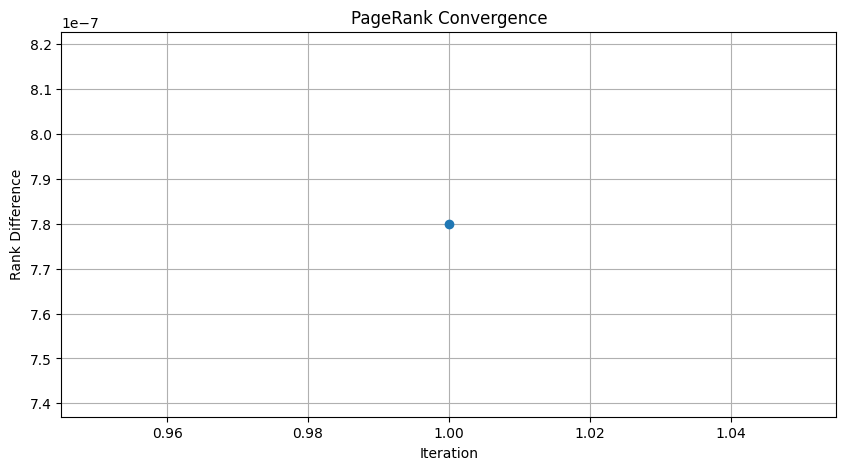

In [26]:
iterations = list(
    range(1, len(convergence_history) + 1)
)

plt.figure(figsize=(10, 5))

plt.plot(
    iterations,
    convergence_history,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Rank Difference")
plt.title("PageRank Convergence")

plt.grid(True)
plt.show()

In [27]:
print("=" * 45)
print("DISTRIBUTED PAGERANK - FINAL RESULTS")
print("=" * 45)

print("Total Documents :", NUM_NODES)
print("Total Links     :", len(edges))
print("RDD Partitions  :", edges_rdd.getNumPartitions())
print("Iterations      :", len(convergence_history))
print("Final Difference:", convergence_history[-1])
print("Total PageRank  :", total_rank)

print("=" * 45)

DISTRIBUTED PAGERANK - FINAL RESULTS
Total Documents : 5000
Total Links     : 25000
RDD Partitions  : 2
Iterations      : 1
Final Difference: 7.798974832966379e-07
Total PageRank  : 1.0


In [28]:
spark.stop()

print("Spark session stopped.")

Spark session stopped.
